# Numerical validation

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import torch
torch.set_printoptions(precision=2)
from torch import nn
import torch.nn.functional as F

from cnst_model import CModel
from lloyds import kmeans_obj, lloyds_algorithm
import tqdm
import multiprocessing as mp
    

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Define parameters and plotting function

In [2]:
#### Default simulation parmaeters 
seed = 5487
niters = 10 # number of iterations to optimize
nclusters = 5 
ndims = 2 # embedding dimension for samples
npoints = 10000 # number of samples
itemp = 10000 # inverse temperature (gamma)
ub = 5 # Upperbound scaling parameter
scaled = True


# Figure parameters
asize=6 # tick label size
tsize=8 # title label size

def plot_center_path(ax, nclusters, centers, marker, colors, msize, head_width=0.1, label=None):
  # plot paths
  for i in range(len(centers) - 1):
    line = centers[i:i+2]
    for j in range(nclusters):
      start, end = line[0][j], line[1][j]
      ax.arrow(
        start[0], start[1],
        end[0]-start[0], end[1]-start[1],
        color=colors[j], linestyle=':', linewidth=1,
        length_includes_head=True,
        head_width=head_width,
      )
  # plot centers
  for i, c in enumerate(centers):
    ax.scatter(c[:, 0], c[:,1], marker=marker, color=colors, s=msize, label=label if i == 0 else None)
  return ax

#### Initialize points

In [3]:
# Set seeds for experiment
RNG = np.random.RandomState(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


# Ingest / generate data
true_centers = torch.rand([nclusters, ndims])
X = []
for loc in true_centers:
    nsamples = npoints // nclusters
    m = torch.distributions.MultivariateNormal(loc=loc, covariance_matrix=0.01 * torch.eye(loc.shape[-1]))
    X += [m.sample() for _ in range(nsamples)]
X = torch.reshape(torch.cat(X), (len(X), ndims))
if scaled:
    minX, _ = X.min(dim=0)
    assert minX.size(0) == ndims
    X = X - minX
    true_centers = true_centers - minX
    maxX, _ = X.max(dim=0)
    X = X / maxX
    true_centers = true_centers / maxX

X = X[torch.randperm(X.size()[0])]
init_centers = X[:nclusters].clone().detach()

# Run Lloyd's algorithm and transformer implementation

In [4]:
lloyd_centers, lloyd_objs, cc = lloyds_algorithm(X, init_centers, niters, nclusters, ndims, use_cuda=False)

# Pre-process data with labels
XX = torch.hstack([X.to('cpu'), torch.zeros(X.size()[0], nclusters)])
CC = torch.hstack([init_centers.clone().detach(), torch.eye(nclusters)])
assert XX.shape[-1] == CC.shape[-1] == ndims + nclusters

trf_centers = [CC[:, :ndims].clone().detach()]

model = CModel(
        ndims,
        nclusters,
        itemp,
        osa=True,
        ldp=True
    )

ttime = time.time()
with torch.no_grad():
    for i in range(niters):
        XX, CC = model(XX,CC)
        # track centers
        trf_centers += [CC[:, :ndims].clone().detach().to('cpu')]
    YY = XX[:, -nclusters:].clone().detach().to('cpu').numpy().astype(int)
    print(YY.shape)
print(f"Trf takes {time.time() - ttime:.3f} secs")
trf_objs = [torch.log(kmeans_obj(X.to('cpu'), cc)) for cc in trf_centers]
print("Trf objs\n", trf_objs)

(10000, 5)
Trf takes 0.006 secs
Trf objs
 [tensor(6.44), tensor(5.78), tensor(5.47), tensor(4.96), tensor(4.69), tensor(4.61), tensor(4.59), tensor(4.59), tensor(4.59), tensor(4.59), tensor(4.59)]


#### Implement transformer variant

per-cluster colors: [(0.4, 0.7607843137254902, 0.6470588235294118), (0.9882352941176471, 0.5529411764705883, 0.3843137254901961), (0.5529411764705883, 0.6274509803921569, 0.796078431372549), (0.9058823529411765, 0.5411764705882353, 0.7647058823529411), (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)]
Trf's res printed
Trf generates discrete assignment for 9921/10000 points


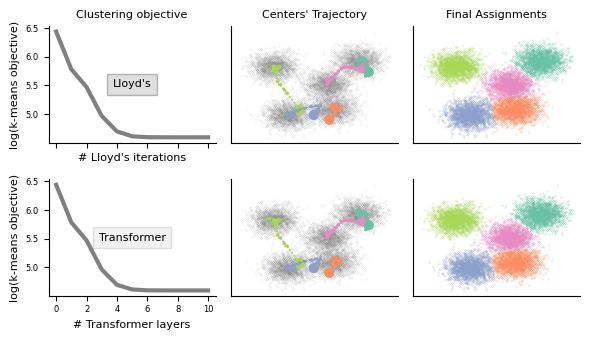

In [5]:

all_colors = [
        c for c in matplotlib.colors.CSS4_COLORS.keys()
        if c not in [
                "white", "antiquewhite", "beige", "ivory", "yellow", "azure", "bisque",
                "aqua", "blanchedalmond", "whitesmoke", "lemonchiffon", "cyan", "wheat",
                "ghostwhite", "palegoldenrod", "gold", "seashell", "paleturquoise", "silver",
                "lightskyblue", "lightsalmon", 'linen', 'mintcream', 'peachpuff', 'slategray',
                "honeydew", "moccasin", "mediumspringgreen", 'oldlace', 'rebeccapurple', 'thistle',
                "floralwhite", "gray", "darkgray", "lawngreen"
        ]
]
idxs = np.arange(len(all_colors))
np.random.shuffle(idxs)
colors = [all_colors[idxs[i]] for i in range(nclusters)]
colors = sns.color_palette("Set2")[:nclusters]
print(f"per-cluster colors: {colors}")

# plot data
nrows = 2
ncols = 3 if ndims == 2 else 1
fig, axs = plt.subplots(
		nrows, ncols, figsize=(6,3.5), sharex='col', sharey='col',
)

# plot kmeans obj
ax = axs[0, 0] if ndims == 2 else axs[0]
ax.plot(
		np.arange(niters+1), lloyd_objs,
		color='gray', label="Lloyd's", linewidth=3
)
ax.set_xlabel("# Lloyd's iterations", fontsize=tsize)
ax.set_ylabel("log(k-means objective)", fontsize=tsize)
ax.set_title("Clustering objective", fontsize=tsize)
ax.tick_params(labelsize=asize)
ax.text(
		0.5, 0.5, "Lloyd's",
		horizontalalignment='center', verticalalignment='center',
		transform=ax.transAxes, fontsize=tsize,
		bbox=dict(facecolor='gray', alpha=0.25)
)

if ndims == 2:
    # plot centers traj
    ax = axs[0, 1]
    ax.scatter(
            X[:, 0], X[:, 1],
            marker='.', color='grey', label='Samples', s=0.01
    )
    ax.scatter(
            init_centers[:,0], init_centers[:,1],
            marker='o', color=colors, label='Init', s=40
    )
    ax = plot_center_path(
            ax, nclusters, lloyd_centers, marker='*', colors=colors, msize=3, head_width=0.03, label="Lloyd's"
    )
    ax.tick_params(axis='both', which='both', bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title("Centers' Trajectory", fontsize=tsize)
    
    # plot final assignments
    ax = axs[0, 2]
    for i in range(nclusters):
        XX = X[cc == i]
        ax.scatter(
            XX[:, 0], XX[:, 1],
            marker='.', color=colors[i], label='Samples', s=0.1
        )
    ax.tick_params(axis='both', which='both', bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title("Final Assignments", fontsize=tsize)

fig.tight_layout()

# plot kmeans obj
ax = axs[1, 0] if ndims == 2 else axs[1]
ax.plot(
        np.arange(niters+1), trf_objs,
        color='gray', label="Transformer", linewidth=3
)
ax.set_xlabel("# Transformer layers", fontsize=tsize)
ax.set_ylabel("log(k-means objective)", fontsize=tsize)
ax.tick_params(labelsize=asize)
ax.text(
    0.5, 0.5, "Transformer",
    horizontalalignment='center', verticalalignment='center',
    transform=ax.transAxes, fontsize=tsize,
    bbox=dict(facecolor='gray', alpha=0.1)
)

if ndims == 2:
    # plot centers traj
    ax = axs[1, 1]
    ax.scatter(
        X[:, 0], X[:, 1],
        marker='.', color='grey', label='Samples', s=0.01
    )
    ax.scatter(
        init_centers[:,0], init_centers[:,1],
        marker='o', color=colors, label='Init', s=40
    )
    ax = plot_center_path(
        ax, nclusters, trf_centers, marker='^', colors=colors, msize=3, head_width=0.03, label="Transformer"
    )
    ax.tick_params(axis='both', which='both', bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # plot final assignments
    ax = axs[1, 2]
    for i in range(nclusters):
        XX = X[YY[:, i] == 1]
        ax.scatter(
        XX[:, 0], XX[:, 1],
        marker='.', color=colors[i], label='Samples', s=0.1
        )
    ax.tick_params(axis='both',  which='both', bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    sns.despine()


fig.tight_layout()
fig.savefig(f'results/clustering_trajectory_example.pdf',transparent=True)
print("Trf's res printed")
trf_rows_plotted = np.sum([
    X[YY[:, i] == 1].shape[0] for i in range(nclusters)
])
print(f"Trf generates discrete assignment for {trf_rows_plotted}/{X.shape[0]} points")